In [ ]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, classification_report

np.random.seed(0)
random.seed(0)

In [2]:
penguins_df = pd.read_csv("data/palmerpenguins_extended.csv")

## EDA

In [3]:
penguins_df_filtered = penguins_df[(penguins_df['life_stage'] == 'adult') & (penguins_df['health_metrics'] == 'healthy')]
penguins_df_filtered

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,diet,life_stage,health_metrics,year
12,Adelie,Biscoe,57.4,19.5,255.0,5920.0,male,fish,adult,healthy,2021
21,Adelie,Biscoe,32.9,20.2,231.0,5431.0,male,krill,adult,healthy,2021
52,Adelie,Dream,65.2,18.0,223.0,4681.0,female,fish,adult,healthy,2021
59,Adelie,Dream,62.9,16.0,249.0,5886.0,male,fish,adult,healthy,2021
60,Adelie,Dream,26.3,18.6,202.0,4242.0,female,krill,adult,healthy,2021
...,...,...,...,...,...,...,...,...,...,...,...
3422,Gentoo,Biscoe,48.7,18.3,243.0,6643.0,male,squid,adult,healthy,2025
3425,Gentoo,Biscoe,44.0,20.4,252.0,6447.0,male,squid,adult,healthy,2025
3426,Gentoo,Biscoe,54.5,25.2,245.0,6872.0,male,squid,adult,healthy,2025
3428,Gentoo,Biscoe,55.9,20.5,247.0,6491.0,male,squid,adult,healthy,2025


In [4]:
penguins_df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 362 entries, 12 to 3429
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            362 non-null    object 
 1   island             362 non-null    object 
 2   bill_length_mm     362 non-null    float64
 3   bill_depth_mm      362 non-null    float64
 4   flipper_length_mm  362 non-null    float64
 5   body_mass_g        362 non-null    float64
 6   sex                362 non-null    object 
 7   diet               362 non-null    object 
 8   life_stage         362 non-null    object 
 9   health_metrics     362 non-null    object 
 10  year               362 non-null    int64  
dtypes: float64(4), int64(1), object(6)
memory usage: 33.9+ KB


In [5]:
print("Number of samples in dataset: {}\n".format(penguins_df_filtered.shape[0]))
print(penguins_df_filtered["species"].value_counts())

Number of samples in dataset: 362

Adelie       159
Gentoo       130
Chinstrap     73
Name: species, dtype: int64


In [6]:
print("Checking for null values in feature columns:\n")
print(penguins_df_filtered.isnull().sum())

Checking for null values in feature columns:

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
diet                 0
life_stage           0
health_metrics       0
year                 0
dtype: int64


_We see that there are 362 penguin samples in our training dataset: 159 Adelie penguins, 130 Gentoo penguins, and 73 Chinstrap penguins. Class imbalance could be an issue. None of the columns have missing values._

_It seems like that our training dataset contains a mix of numerical columns (bill length, bill depth, flipper length, body mass), categorical columns (island, diet, year), and binary columns (sex). Note that we are ignoring the life stage and health metrics columns since we are only analyzing penguins that are adults and that are healthy._

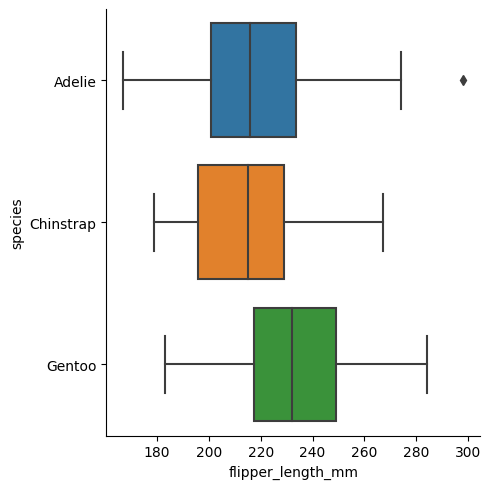

In [7]:
sns.catplot(data=penguins_df_filtered, x="flipper_length_mm", y="species", kind="box")
plt.show()

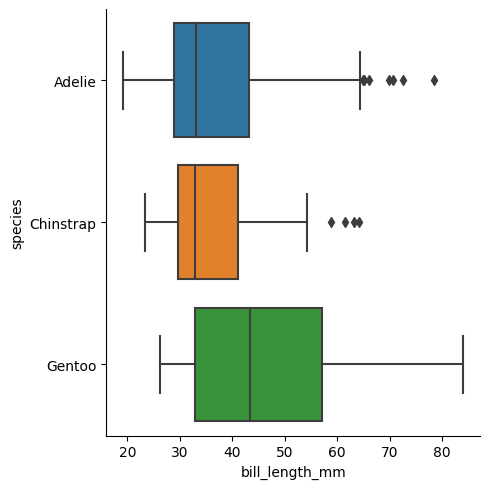

In [8]:
sns.catplot(data=penguins_df_filtered, x="bill_length_mm", y="species", kind="box")
plt.show()

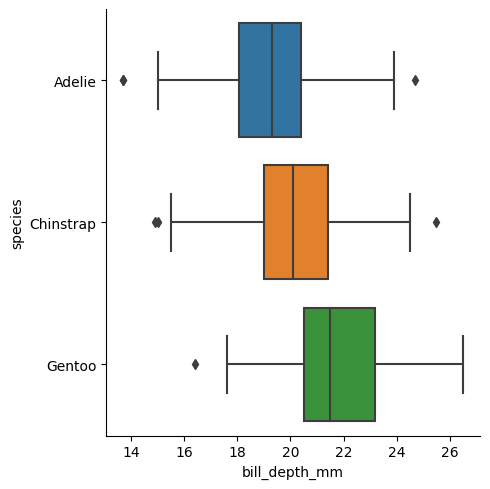

In [9]:
sns.catplot(data=penguins_df_filtered, x="bill_depth_mm", y="species", kind="box")
plt.show()

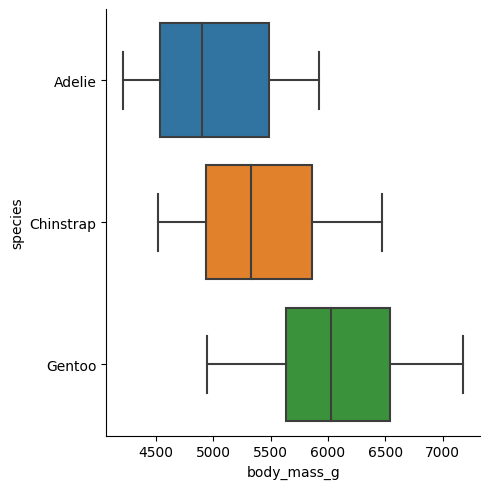

In [10]:
sns.catplot(data=penguins_df_filtered, x="body_mass_g", y="species", kind="box")
plt.show()

_Flipper length: Gentoo penguins on average seem to have the longest bills. Adelie penguins and Chinstrap penguins seem to have shorter bill lengths, but between these two species their bill lengths are quite similar._

_Bill length: Gentoo penguins on average seems to have the longest bills. Adelie penguins and Chinstrap penguins seem to have similar bill lengths, with Adelie penguins having a larger spread of bill lengths._

_Bill depth: Gentoo penguins on average has the largest bill depth. Adelie penguins have the smallest bill depth on average._

_Body Mass: Gentoo penguins on average has the largest body mass. Adelie penguins have the smallest body mass on average._

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


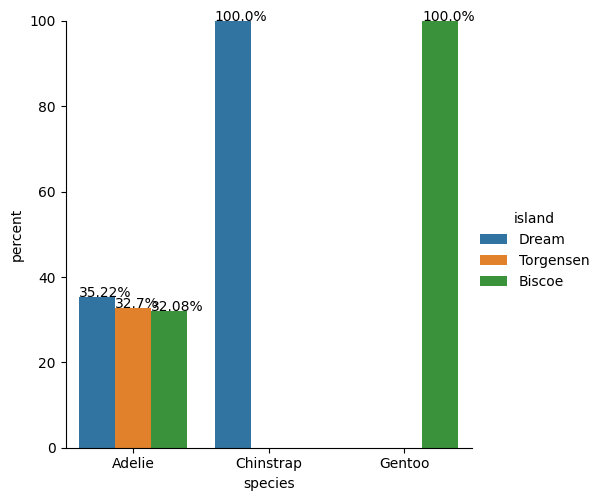

In [11]:
x,y = 'species', 'island'

df1 = penguins_df_filtered.groupby(x)[y].value_counts(normalize=True)
df1 = df1.mul(100)
df1 = df1.rename('percent').reset_index()

g = sns.catplot(x=x,y='percent',hue=y,kind='bar',data=df1)
g.ax.set_ylim(0,100)

for p in g.ax.patches:
    txt = str(p.get_height().round(2)) + '%'
    txt_x = p.get_x() 
    txt_y = p.get_height()
    g.ax.text(txt_x,txt_y,txt)

_We see that all Chinstrap penguins were found on Dream island and all Gentoo penguins were found on Biscoe island. However, Adelie penguins were found on Dream, Biscoe, and Torgensen and the number of Adelie penguins found on each island were quite evenly distributed._

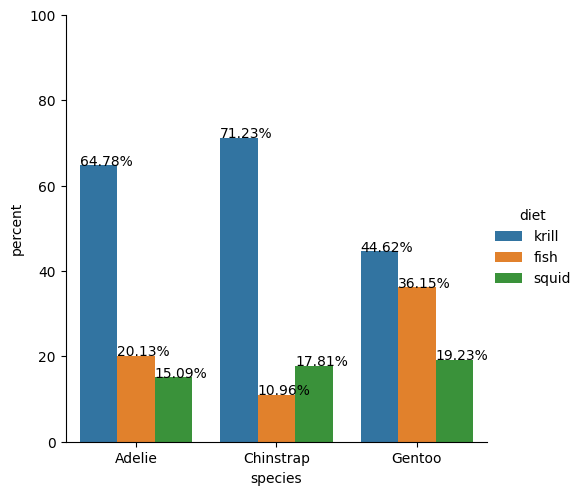

In [12]:
x,y = 'species', 'diet'

df1 = penguins_df_filtered.groupby(x)[y].value_counts(normalize=True)
df1 = df1.mul(100)
df1 = df1.rename('percent').reset_index()

g = sns.catplot(x=x,y='percent',hue=y,kind='bar',data=df1)
g.ax.set_ylim(0,100)

for p in g.ax.patches:
    txt = str(p.get_height().round(2)) + '%'
    txt_x = p.get_x() 
    txt_y = p.get_height()
    g.ax.text(txt_x,txt_y,txt)

_We see that krill is the most popular diet for all three penguin species, the Chinstrap species having the largest percentage of penguins having krill as their primary diet (71.23%) with Adelie following closely in second (64.78%). Compared to the other species, Gentoo has the highest percentage of penguins that consume fish as their primary diet (36.15%) whereas Chinstrap has the lowest percentage (10.96%). The percentage of penguins that consume squid as their primary diet is the most similar across all species, with Gentoo also having the highest percentage (19.23%) compared to other species, and Adelie having the lowest (15.09%)._

In [13]:
pivot_table_result = pd.pivot_table(penguins_df_filtered,
                                    values=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'],
                                    index=['year'],
                                    aggfunc=['mean'])

pivot_table_result.round(1)

mean                                             
     bill_depth_mm bill_length_mm body_mass_g flipper_length_mm
year                                                           
2021          20.6           44.5      5520.6             228.2
2022          20.7           38.5      5538.5             223.5
2023          20.6           39.7      5475.0             220.2
2024          20.1           41.9      5452.1             223.1
2025          20.1           38.6      5402.5             222.7

_While there are slight fluctuations in penguin features over the years, the changes are minimal and do not seem to follow a trend. They do not seem to be substantial. This consistency could imply stable environmental conditions or successful adaptation strategies over the observed years._

## Data Splitting

_We will go with a 80/20 training/testing split since the dataset we have is small._

In [14]:
train_df, test_df = train_test_split(penguins_df_filtered, test_size=0.20, random_state=123) 
X_train, y_train = train_df.drop(columns=["species"]), train_df["species"]
X_test, y_test = test_df.drop(columns=["species"]), test_df["species"]

In [15]:
print("Number of samples in train dataset: {}".format(train_df.shape[0]))
print(train_df['species'].value_counts())

print("\nNumber of samples in test dataset: {}".format(test_df.shape[0]))
print(test_df["species"].value_counts())

Number of samples in train dataset: 289
Adelie       131
Gentoo       100
Chinstrap     58
Name: species, dtype: int64

Number of samples in test dataset: 73
Gentoo       30
Adelie       28
Chinstrap    15
Name: species, dtype: int64


## Preprocessing

In [16]:
numeric_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
categorical_features = ['island', 'diet']
binary_features = ['sex']
drop_features = ['year', 'life_stage', 'health_metrics']
target_feature = ['species']

In [17]:
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown="ignore")

binary_transformer = OneHotEncoder(drop="if_binary", dtype=int)

preprocessor = make_column_transformer(
    (numeric_transformer, numeric_features),
    (categorical_transformer, categorical_features),
    (binary_transformer, binary_features),
    ("drop", drop_features),
)
preprocessor

ColumnTransformer(transformers=[('standardscaler', StandardScaler(),
                                 ['bill_length_mm', 'bill_depth_mm',
                                  'flipper_length_mm', 'body_mass_g']),
                                ('onehotencoder-1',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['island', 'diet']),
                                ('onehotencoder-2',
                                 OneHotEncoder(drop='if_binary',
                                               dtype=<class 'int'>),
                                 ['sex']),
                                ('drop', 'drop',
                                 ['year', 'life_stage', 'health_metrics'])])

## Baseline Model

In [18]:
pipe_rf = make_pipeline(
    preprocessor,
    RandomForestClassifier(
        n_estimators=10,
        max_depth=5,
        random_state=123,
    ),
)

# Cross Validation
scores = cross_validate(pipe_rf, X_train, y_train, return_train_score=True)
print(pd.DataFrame(scores))
print("\nMean cross-validation score: {}".format(scores['test_score'].mean()))

   fit_time  score_time  test_score  train_score
0  0.073319    0.016224    0.775862     0.909091
1  0.058618    0.024014    0.844828     0.930736
2  0.065761    0.016482    0.896552     0.952381
3  0.079765    0.021260    0.862069     0.917749
4  0.075297    0.014083    0.877193     0.900862

Mean cross-validation score: 0.8513006654567453


_Cross-validation scores vary significantly. This could be due to the small dataset and the class imbalance._

In [19]:
# Fit the model
pipe_rf.fit(X_train, y_train)

# Make predictions
y_pred = pipe_rf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Test Accuracy: 0.821917808219178

Classification Report:
               precision    recall  f1-score   support

      Adelie       0.83      0.68      0.75        28
   Chinstrap       0.69      0.73      0.71        15
      Gentoo       0.88      1.00      0.94        30

    accuracy                           0.82        73
   macro avg       0.80      0.80      0.80        73
weighted avg       0.82      0.82      0.82        73



### Hyperparameter Tuning

In [20]:
# Get step names and parameter names for each step
print(pipe_rf.steps)  # Viewing step names

rf_params = pipe_rf.named_steps['randomforestclassifier'].get_params() # Get all parameters for the 'svc' step
print(rf_params)

[('columntransformer', ColumnTransformer(transformers=[('standardscaler', StandardScaler(),
                                 ['bill_length_mm', 'bill_depth_mm',
                                  'flipper_length_mm', 'body_mass_g']),
                                ('onehotencoder-1',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['island', 'diet']),
                                ('onehotencoder-2',
                                 OneHotEncoder(drop='if_binary',
                                               dtype=<class 'int'>),
                                 ['sex']),
                                ('drop', 'drop',
                                 ['year', 'life_stage', 'health_metrics'])])), ('randomforestclassifier', RandomForestClassifier(max_depth=5, n_estimators=10, random_state=123))]
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'max_leaf_

In [21]:
# Find best parameter of a model using GridSearchCV
def find_best_param(model, X_train: pd.Series, y_train: pd.Series, space: dict, cv: KFold) -> None:
    grid = GridSearchCV(model, space, scoring='accuracy', n_jobs=-1, cv=cv)
    grid.fit(X_train, y_train)
    
    best_param = grid.best_params_
    print(best_param)

n_folds = 5

# configure the cross-validation procedure
cv = KFold(n_splits=n_folds, shuffle=True, random_state=1)

param_grid = {
    "randomforestclassifier__n_estimators": [50, 100, 120, 140, 160, 180, 200],
    "randomforestclassifier__max_depth": [5, 10, 15, 20, 25],
}

find_best_param(pipe_rf, X_train, y_train, param_grid, cv)

{'randomforestclassifier__max_depth': 10, 'randomforestclassifier__n_estimators': 180}


## Model Training

In [22]:
pipe_rf = make_pipeline(
    preprocessor,
    RandomForestClassifier(
        n_estimators=180,
        max_depth=10,
        random_state=123,
    ),
)

# Fit the model
pipe_rf.fit(X_train, y_train)

# Make predictions
y_pred = pipe_rf.predict(X_test)

# Cross Validation
scores = cross_validate(pipe_rf, X_train, y_train, return_train_score=True)
print(pd.DataFrame(scores))
print("\nMean cross-validation score: {}".format(scores['test_score'].mean()))

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

   fit_time  score_time  test_score  train_score
0  0.720711    0.045090    0.862069          1.0
1  0.661190    0.046610    0.844828          1.0
2  0.684558    0.039852    0.879310          1.0
3  0.705230    0.040469    0.931034          1.0
4  0.673519    0.045855    0.912281          1.0

Mean cross-validation score: 0.8859044162129461
Test Accuracy: 0.9041095890410958

Classification Report:
               precision    recall  f1-score   support

      Adelie       0.86      0.89      0.88        28
   Chinstrap       0.92      0.73      0.81        15
      Gentoo       0.94      1.00      0.97        30

    accuracy                           0.90        73
   macro avg       0.91      0.88      0.89        73
weighted avg       0.90      0.90      0.90        73

